## Data quality check / cleaning / preparation 

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.** An example is given below.

In [68]:
#importing packages from textbook

import pandas as pd
import numpy as np

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for better display in Jupyter
%matplotlib inline

# Set default figure size for all plots (width, height in inches)
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 5)  # Larger default size
matplotlib.rcParams['figure.dpi'] = 100          # Resolution
matplotlib.rcParams['font.size'] = 11            # Default font size

# Configure Seaborn style
sns.set_palette("deep")                          # Colorblind-friendly palette
sns.set_context("notebook")                      # Appropriate scaling

#for geospacial plotting
import warnings
# Suppress all non-critical warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
import geopandas 
import folium
import geodatasets

### Importing Data
*By Jenna Krinsky*

In [70]:
#Using Divvy Data from 2024 - 2025 (as of October)
#ChatGPT gave a way to read/combine all datasets without having to merge and import each individually


import glob 

files = glob.glob("/Users/jennakrinsky/Desktop/STAT 303_1/Final/DivvyData/*.csv")   

dfs = []                                      # empty list to store DataFrames
for f in files:
    dfs.append(pd.read_csv(f))

divvy = pd.concat(dfs, ignore_index=True)

In [71]:
#chronological order (same as Grace)
divvy["started_at"] = pd.to_datetime(divvy["started_at"], format="mixed")
divvy = divvy.sort_values(by="started_at")

In [ ]:
divvy.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
3486147,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.950000,-87.650000,41.929546,-87.643118,member
3491360,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3486040,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3467452,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,Clinton St & Madison St,TA1305000032,NaN,NaN,41.881909,-87.641296,41.890000,-87.620000,member
3410785,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,LaSalle St & Illinois St,13430,Indiana Ave & Roosevelt Rd,SL-005,41.890762,-87.631697,41.867888,-87.623041,member


In [72]:
#import other datasets

routes0 = pd.read_csv("Bike_Routes_20251206.csv")
stations = pd.read_csv("Divvy_Bicycle_Stations_20251206.csv")
boundaries = pd.read_csv("CensusTractsTIGER2010_20251206.csv")
demographic = pd.read_csv("ACS_5_Year_Data_by_Community_Area_-_Most_Recent_Year_20251206.csv")


In [ ]:
routes0.head()

,the_geom,STREET,ST_NAME,ONEWAY_DIR,F_STREET,T_STREET,DISPLAYROU,MI_CTRLINE,BR_ONEWAY,BR_OW_DIR,CONTRAFLOW
0,MULTILINESTRING ((-87.70296713856047 41.771674...,MARQUETTE RD,MARQUETTE,-,S CENTRAL PARK AVE,S KEDZIE AVE,BUFFERED,0.495171,NaN,NaN,NaN
1,MULTILINESTRING ((-87.69808324194773 41.771749...,MARQUETTE RD,MARQUETTE,-,S KEDZIE AVE,S SACRAMENTO AVE,SHARED,0.252404,NaN,NaN,NaN
2,MULTILINESTRING ((-87.54814956426897 41.751975...,LAKE SHORE DR,LAKE SHORE,-,E 87TH ST,E 79TH ST,BUFFERED,1.244230,NaN,NaN,NaN
3,MULTILINESTRING ((-87.63381261441066 41.881289...,WELLS ST,WELLS,S,W VAN BUREN ST,W WACKER DR,SHARED,0.696352,Y,S,NaN
4,MULTILINESTRING ((-87.59169592896838 41.795509...,55TH PL,55TH,W,S DORCHESTER AVE,E 55TH ST,BUFFERED,0.140521,Y,W,NaN


In [ ]:
stations.head()

,ID,Station Name,Short Name,Total Docks,Docks in Service,Status,Latitude,Longitude,Location
0,1859717767703464460,Kedzie Ave & Redfield Dr,CHI01795,15,15,In Service,41.765230,-87.703160,POINT (-87.70316 41.76523)
1,1861588043429399408,McCormick Blvd & Devon Ave,CHI01881,11,11,In Service,41.997200,-87.711050,POINT (-87.71105 41.9972)
2,a3af1767-a135-11e9-9cda-0a87ae2ba916,Broadway & Granville Ave,CHI00563,23,23,In Service,41.994780,-87.660285,POINT (-87.6602845349 41.9947796884)
3,a3aa91f4-a135-11e9-9cda-0a87ae2ba916,Greenview Ave & Diversey Pkwy,CHI00382,15,15,In Service,41.932590,-87.665936,POINT (-87.665936350822 41.932589634298)
4,a3aa9732-a135-11e9-9cda-0a87ae2ba916,Loomis St & Lexington St,CHI00238,20,20,In Service,41.872229,-87.661364,POINT (-87.661363855004 41.87222873224)


In [ ]:
boundaries.head()

,the_geom,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,COMMAREA,COMMAREA_N,NOTES
0,MULTIPOLYGON (((-87.62404799998049 41.73021699...,17,31,842400,17031842400,8424.0,Census Tract 8424,44,44,NaN
1,MULTIPOLYGON (((-87.6860799999848 41.822956000...,17,31,840300,17031840300,8403.0,Census Tract 8403,59,59,NaN
2,MULTIPOLYGON (((-87.62934700001182 41.85279700...,17,31,841100,17031841100,8411.0,Census Tract 8411,34,34,NaN
3,MULTIPOLYGON (((-87.68813499997718 41.85569099...,17,31,841200,17031841200,8412.0,Census Tract 8412,31,31,NaN
4,MULTIPOLYGON (((-87.63312200003458 41.87448800...,17,31,839000,17031839000,8390.0,Census Tract 8390,32,32,NaN


In [73]:
demographic.head()

,ACS Year,Community Area,"Under $25,000","$25,000 to $49,999","$50,000 to $74,999","$75,000 to $125,000","$125,000 +",Male 0 to 17,Male 18 to 24,Male 25 to 34,...,White,Black or African American,American Indian or Alaska Native,Asian,Native Hawaiian or Pacific Islander,Other Race,Multiracial,White Not Hispanic or Latino,Hispanic or Latino,Record ID
0,2023,ALBANY PARK,"1,269","1,916","1,801","2,306","3,379","4,799","2,955","4,513",...,"21,496","2,228",759,"7,124",1,"7,888","8,334","16,115","21,108",2023_ALBANY PARK
1,2023,ARCHER HEIGHTS,223,752,441,795,739,"1,927",732,"1,102",...,"6,232",10,108,679,0,"3,705","3,142","2,043","11,097",2023_ARCHER HEIGHTS
2,2023,ARMOUR SQUARE,701,798,370,637,597,"1,300",487,871,...,"2,556","1,487",107,"8,402",61,212,325,"2,226",565,2023_ARMOUR SQUARE
3,2023,ASHBURN,797,"1,351","1,985","3,014","2,735","5,150","1,964","2,881",...,"11,297","18,124",697,436,0,"7,772","4,517","3,774","19,917",2023_ASHBURN
4,2023,AUBURN GRESHAM,"2,541","2,451","1,592","2,202","1,850","5,803","1,836","2,964",...,760,"43,414",119,399,0,993,798,491,"1,577",2023_AUBURN GRESHAM


In [74]:
demographic.shape

(77, 30)

### Data cleaning
*By Jenna Krinsky*

In [ ]:
#...Code with comments...#
print(divvy.shape)
divvy.isnull().sum()


(10916400, 13)


ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    2155418
start_station_id      2155418
end_station_name      2236017
end_station_id        2236017
start_lat                   0
start_lng                   0
end_lat                 12288
end_lng                 12288
member_casual               0
dtype: int64

In [ ]:
print(routes0.shape)
routes0.isnull().sum()

(931, 11)


the_geom        0
STREET          0
ST_NAME         0
ONEWAY_DIR      0
F_STREET        0
T_STREET        0
DISPLAYROU      0
MI_CTRLINE      0
BR_ONEWAY     811
BR_OW_DIR     811
CONTRAFLOW    869
dtype: int64

Since the majority of rows, do not contain data on BR_ONEWAY, BR_OW_DIR, or CONTRAFLOW, we can clean the data simply through making a different dataset that excludes those rows. 

In [ ]:
routes = routes0[["the_geom", "STREET", "ST_NAME", "ONEWAY_DIR", "F_STREET", "T_STREET", "DISPLAYROU", "MI_CTRLINE"]]

In [ ]:
routes.isnull().sum()

the_geom      0
STREET        0
ST_NAME       0
ONEWAY_DIR    0
F_STREET      0
T_STREET      0
DISPLAYROU    0
MI_CTRLINE    0
dtype: int64

In [ ]:
print(stations.shape)
stations.isnull().sum()

(1149, 9)


ID                   0
Station Name         0
Short Name          99
Total Docks          0
Docks in Service     0
Status               0
Latitude             0
Longitude            0
Location             0
dtype: int64

In [ ]:
print(demographic.shape)
demographic.isnull().sum()

(77, 30)


ACS Year                               0
Community Area                         0
Under $25,000                          0
$25,000 to $49,999                     0
$50,000 to $74,999                     0
$75,000 to $125,000                    0
$125,000 +                             0
Male 0 to 17                           0
Male 18 to 24                          0
Male 25 to 34                          0
Male 35 to 49                          0
Male 50 to 64                          0
Male 65+                               0
Female 0 to 17                         0
Female 18 to 24                        0
Female 25 to 34                        0
Female 35 to 49                        0
Female 50 to 64                        0
Female 65 +                            0
Total Population                       0
White                                  0
Black or African American              0
American Indian or Alaska Native       0
Asian                                  0
Native Hawaiian 

In [ ]:
demographic["Community Area"]

0        ALBANY PARK
1     ARCHER HEIGHTS
2      ARMOUR SQUARE
3            ASHBURN
4     AUBURN GRESHAM
           ...      
72         WEST LAWN
73      WEST PULLMAN
74        WEST RIDGE
75         WEST TOWN
76          WOODLAWN
Name: Community Area, Length: 77, dtype: object

Overall, the datasets were clean. Although there are missing values in the Divvy dataset, they are mainly categorical variables (Station Names) so they cannot be filled in based on imputation. End Lat/Long are missing for .1% of entries so that does not impact the dataset. 

#### Configuring Neighborhoods
*By Jenna Krinsky*

##### Visualizing Chicago 
*By Jenna Krinsky*

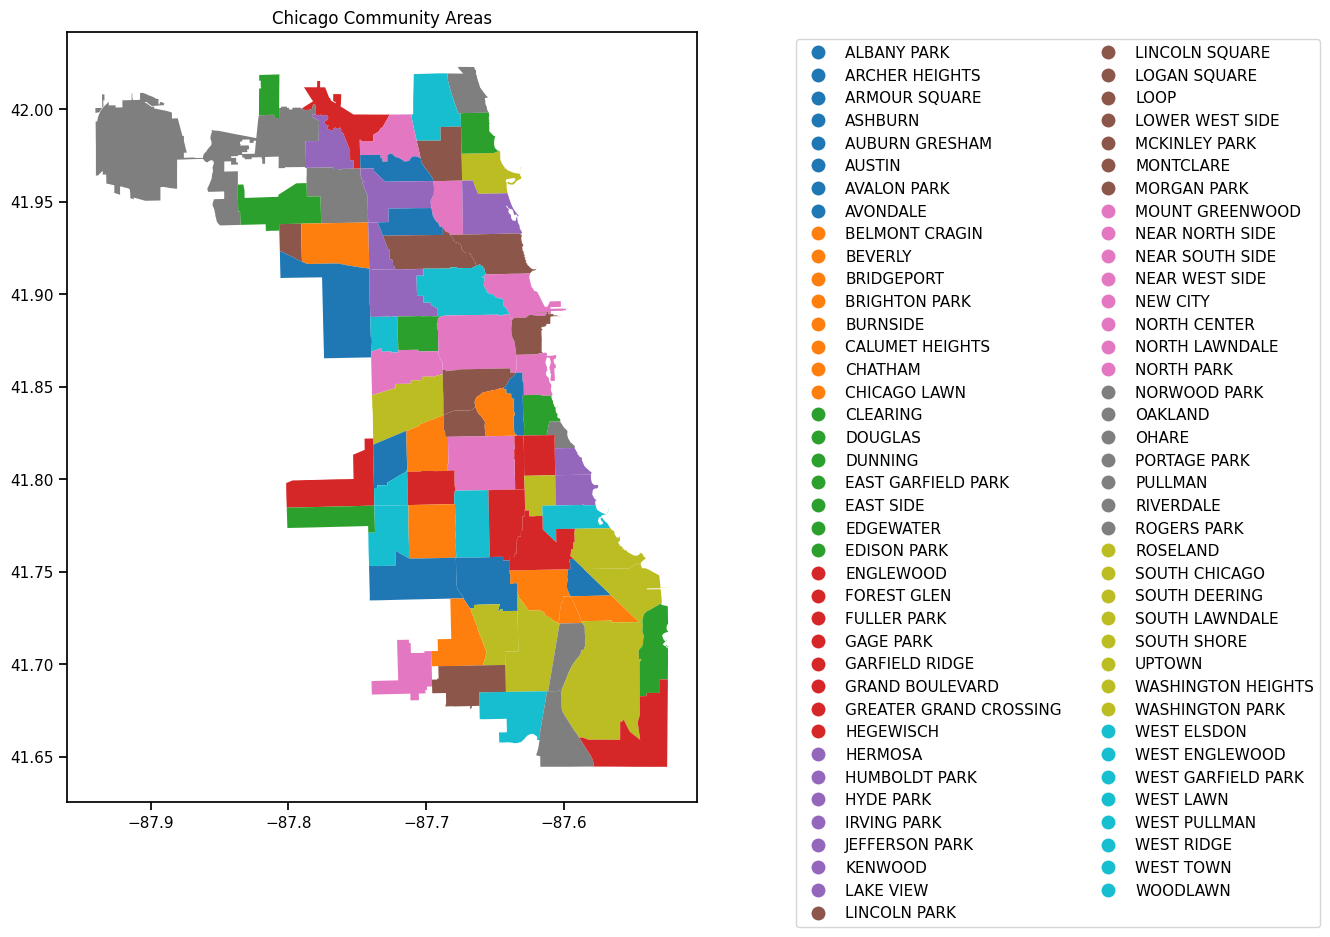

In [ ]:
#FROM TEXTBOOK

# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 10))

# Plot your GeoDataFrame
chicago0 = gpd.read_file(r'/Users/jennakrinsky/Desktop/STAT 303_1/Final/Boundaries - Community Areas_20251206/geo_export_4e5b8e79-ef2a-4393-97e4-7e19e27e3265.shp')
chicago0.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

# Add title (optional)
plt.title('Chicago Community Areas');

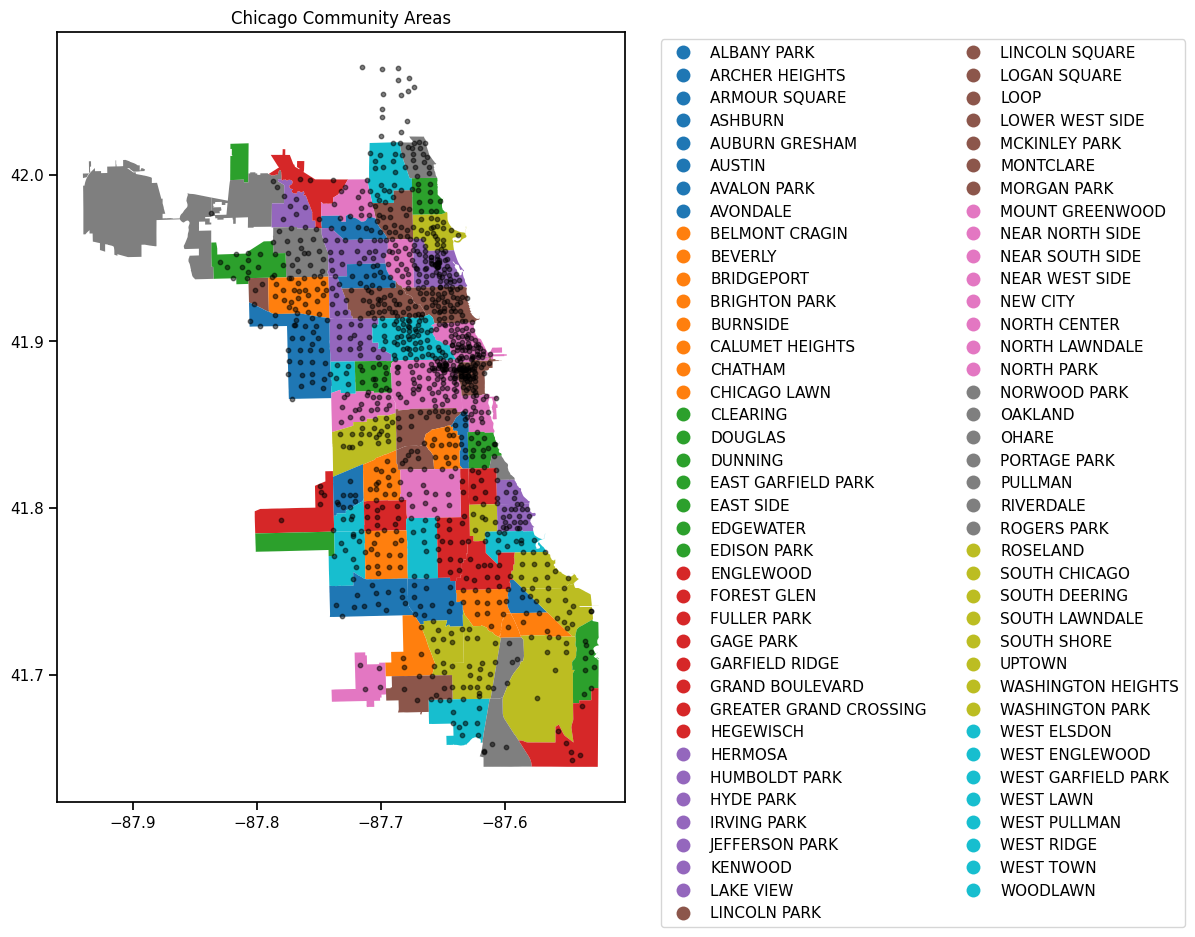

In [ ]:
# Adding the stations to the plot
fig, ax = plt.subplots(figsize=(15, 10))

chicago = gpd.read_file(r'/Users/jennakrinsky/Desktop/STAT 303_1/Final/Boundaries - Community Areas_20251206/geo_export_4e5b8e79-ef2a-4393-97e4-7e19e27e3265.shp')
chicago.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

plt.scatter(stations['Longitude'], stations['Latitude'], s=10, alpha=0.5, color='black', marker='o')
plt.title('Chicago Community Areas');


There are stations North of the city limits. I want to delete these from the dataset to clean it in order to do the rest of my analysis.

In [ ]:
#Cleaning stations so that they are only within the Chicago boundaries

minx, miny, maxx, maxy = chicago.total_bounds

stations_clean = stations[
    (stations['Longitude'] >= minx) &
    (stations['Longitude'] <= maxx) &
    (stations['Latitude']  >= miny) &
    (stations['Latitude']  <= maxy)
]

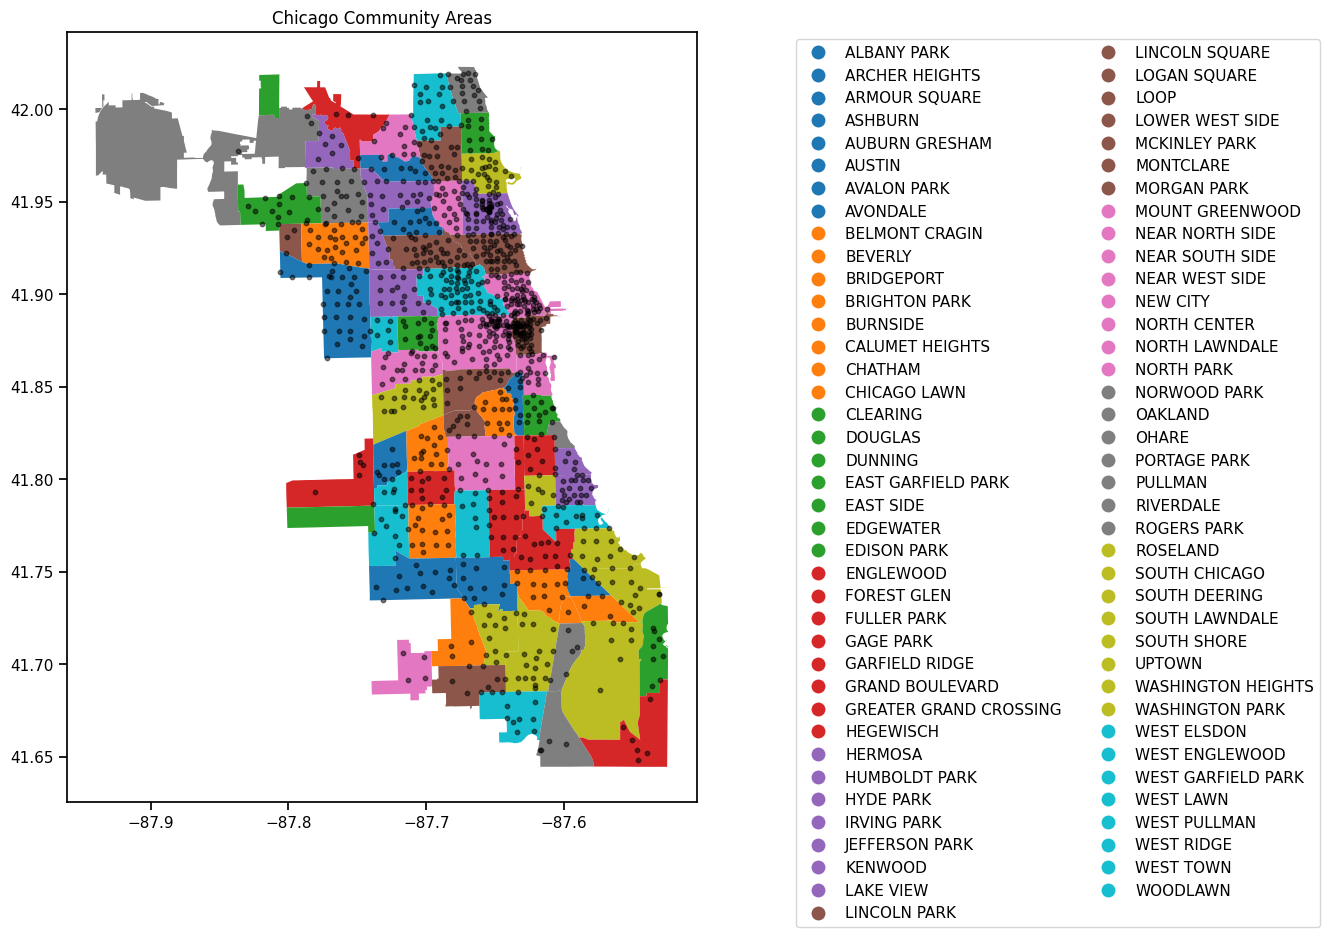

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))

chicago = gpd.read_file(r'/Users/jennakrinsky/Desktop/STAT 303_1/Final/Boundaries - Community Areas_20251206/geo_export_4e5b8e79-ef2a-4393-97e4-7e19e27e3265.shp')
chicago.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

plt.scatter(stations_clean['Longitude'], stations_clean['Latitude'], s=10, alpha=0.5, color='black', marker='o')
plt.title('Chicago Community Areas');

Now all stations are within the city limits!

### Merging Data
*By Jenna Krinsky*

In [75]:
demographic.head()

,ACS Year,Community Area,"Under $25,000","$25,000 to $49,999","$50,000 to $74,999","$75,000 to $125,000","$125,000 +",Male 0 to 17,Male 18 to 24,Male 25 to 34,...,White,Black or African American,American Indian or Alaska Native,Asian,Native Hawaiian or Pacific Islander,Other Race,Multiracial,White Not Hispanic or Latino,Hispanic or Latino,Record ID
0,2023,ALBANY PARK,"1,269","1,916","1,801","2,306","3,379","4,799","2,955","4,513",...,"21,496","2,228",759,"7,124",1,"7,888","8,334","16,115","21,108",2023_ALBANY PARK
1,2023,ARCHER HEIGHTS,223,752,441,795,739,"1,927",732,"1,102",...,"6,232",10,108,679,0,"3,705","3,142","2,043","11,097",2023_ARCHER HEIGHTS
2,2023,ARMOUR SQUARE,701,798,370,637,597,"1,300",487,871,...,"2,556","1,487",107,"8,402",61,212,325,"2,226",565,2023_ARMOUR SQUARE
3,2023,ASHBURN,797,"1,351","1,985","3,014","2,735","5,150","1,964","2,881",...,"11,297","18,124",697,436,0,"7,772","4,517","3,774","19,917",2023_ASHBURN
4,2023,AUBURN GRESHAM,"2,541","2,451","1,592","2,202","1,850","5,803","1,836","2,964",...,760,"43,414",119,399,0,993,798,491,"1,577",2023_AUBURN GRESHAM


In [81]:
demographic['Community Area'] = demographic['Community Area'].str.upper().str.strip()


chicago = chicago.sort_values(by = "community")
chicago['Community Area'] = chicago['community'].str.upper().str.strip()


In [83]:
chicago_dem = chicago.merge(
    demographic,
    on='Community Area',
    how='left'
)
chicago_dem.head()

,area_numbe,community,area_num_1,shape_area,shape_len,geometry,community_name,Community Area,ACS Year,"Under $25,000",...,White,Black or African American,American Indian or Alaska Native,Asian,Native Hawaiian or Pacific Islander,Other Race,Multiracial,White Not Hispanic or Latino,Hispanic or Latino,Record ID
0,14.0,ALBANY PARK,14,5.354223e+07,39339.016439,"POLYGON ((-87.70404 41.97355, -87.70403 41.973...",ALBANY PARK,ALBANY PARK,2023,"1,269",...,"21,496","2,228",759,"7,124",1,"7,888","8,334","16,115","21,108",2023_ALBANY PARK
1,57.0,ARCHER HEIGHTS,57,5.592251e+07,31880.021029,"POLYGON ((-87.71437 41.82604, -87.71436 41.825...",ARCHER HEIGHTS,ARCHER HEIGHTS,2023,223,...,"6,232",10,108,679,0,"3,705","3,142","2,043","11,097",2023_ARCHER HEIGHTS
2,34.0,ARMOUR SQUARE,34,2.776620e+07,31948.598840,"POLYGON ((-87.62917 41.84556, -87.62947 41.845...",ARMOUR SQUARE,ARMOUR SQUARE,2023,701,...,"2,556","1,487",107,"8,402",61,212,325,"2,226",565,2023_ARMOUR SQUARE
3,70.0,ASHBURN,70,1.354603e+08,54818.154632,"POLYGON ((-87.71255 41.75734, -87.71252 41.757...",ASHBURN,ASHBURN,2023,797,...,"11,297","18,124",697,436,0,"7,772","4,517","3,774","19,917",2023_ASHBURN
4,71.0,AUBURN GRESHAM,71,1.050654e+08,46757.721716,"POLYGON ((-87.6399 41.75615, -87.6399 41.75593...",AUBURN GRESHAM,AUBURN GRESHAM,2023,"2,541",...,760,"43,414",119,399,0,993,798,491,"1,577",2023_AUBURN GRESHAM


Now that the datasets are merged, we can make graphs based on demographics. 

### Distribution of Socioeconomic Status
*By Jenna Krinsky*

In [88]:
income_cols = [
    'Under $25,000',
    '$25,000 to $49,999',
    '$50,000 to $74,999',
    '$75,000 to $125,000',
    '$125,000 +',
    'Total Population'
]

# Remove commas and convert to numeric (used AI for help with converting in an efficienct way)
for col in income_cols:
    chicago_dem[col] = (
        chicago_dem[col]
        .astype(str)
        .str.replace(',', '', regex=True)
        .astype(float)
    )

In [99]:
#finding percentages for each income bin to make socioeconomic status graphs

pop = chicago_dem['Under $25,000'] + chicago_dem['$25,000 to $49,999'] + chicago_dem['$50,000 to $74,999'] + chicago_dem['$75,000 to $125,000'] + chicago_dem['$125,000 +']

#divide by total people who report their income NOT the total population because there would be different percentages of responses for each community
chicago_dem['pct_under_25k'] = chicago_dem['Under $25,000'] / (pop) * 100
chicago_dem['pct_25_49k']   = chicago_dem['$25,000 to $49,999'] / (pop) * 100
chicago_dem['pct_50_74k']   = chicago_dem['$50,000 to $74,999'] / (pop) * 100
chicago_dem['pct_75_125k']  = chicago_dem['$75,000 to $125,000'] / (pop) * 100
chicago_dem['pct_125_plus'] = chicago_dem['$125,000 +'] / (pop) * 100


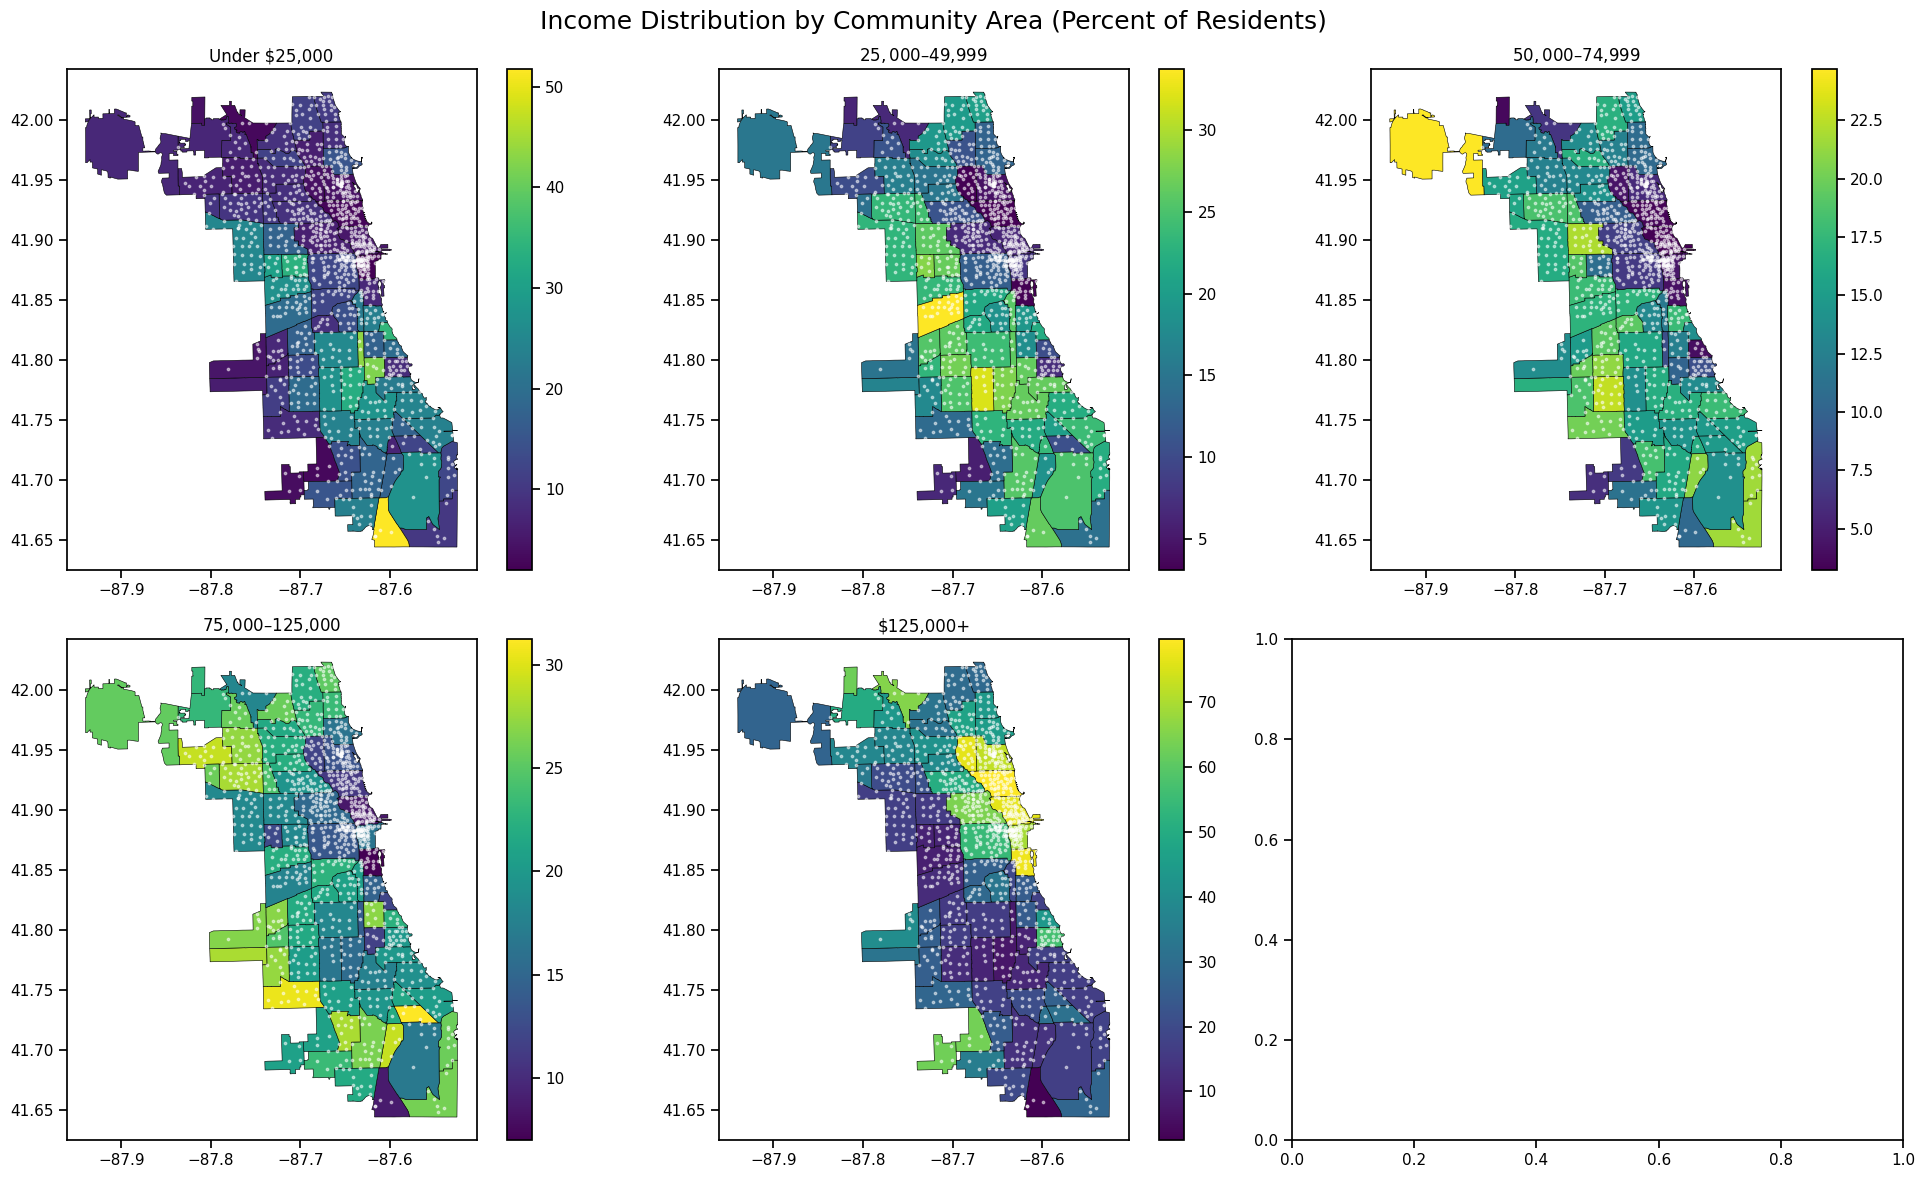

In [158]:
bins = [
    ('pct_under_25k', 'Under $25,000'),
    ('pct_25_49k', '$25,000–$49,999'),
    ('pct_50_74k', '$50,000–$74,999'),
    ('pct_75_125k', '$75,000–$125,000'),
    ('pct_125_plus', '$125,000+')
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(bins):
    chicago_dem.plot(
        column=col,
        cmap='viridis',
        linewidth=0.4,
        edgecolor='black',
        legend=True,
        ax=axes[i]
    )
    axes[i].set_title(label)

    axes[i].scatter(stations_clean['Longitude'], stations_clean['Latitude'], s=3, alpha=0.5, color='white', marker='o')


fig.suptitle("Income Distribution by Community Area (Percent of Residents)", fontsize=18)
plt.tight_layout()
plt.show()

Chlorographs based on income in each community. These are little difficult to interpret, so I will make a different plot to analyze socioeconomic status per community. 

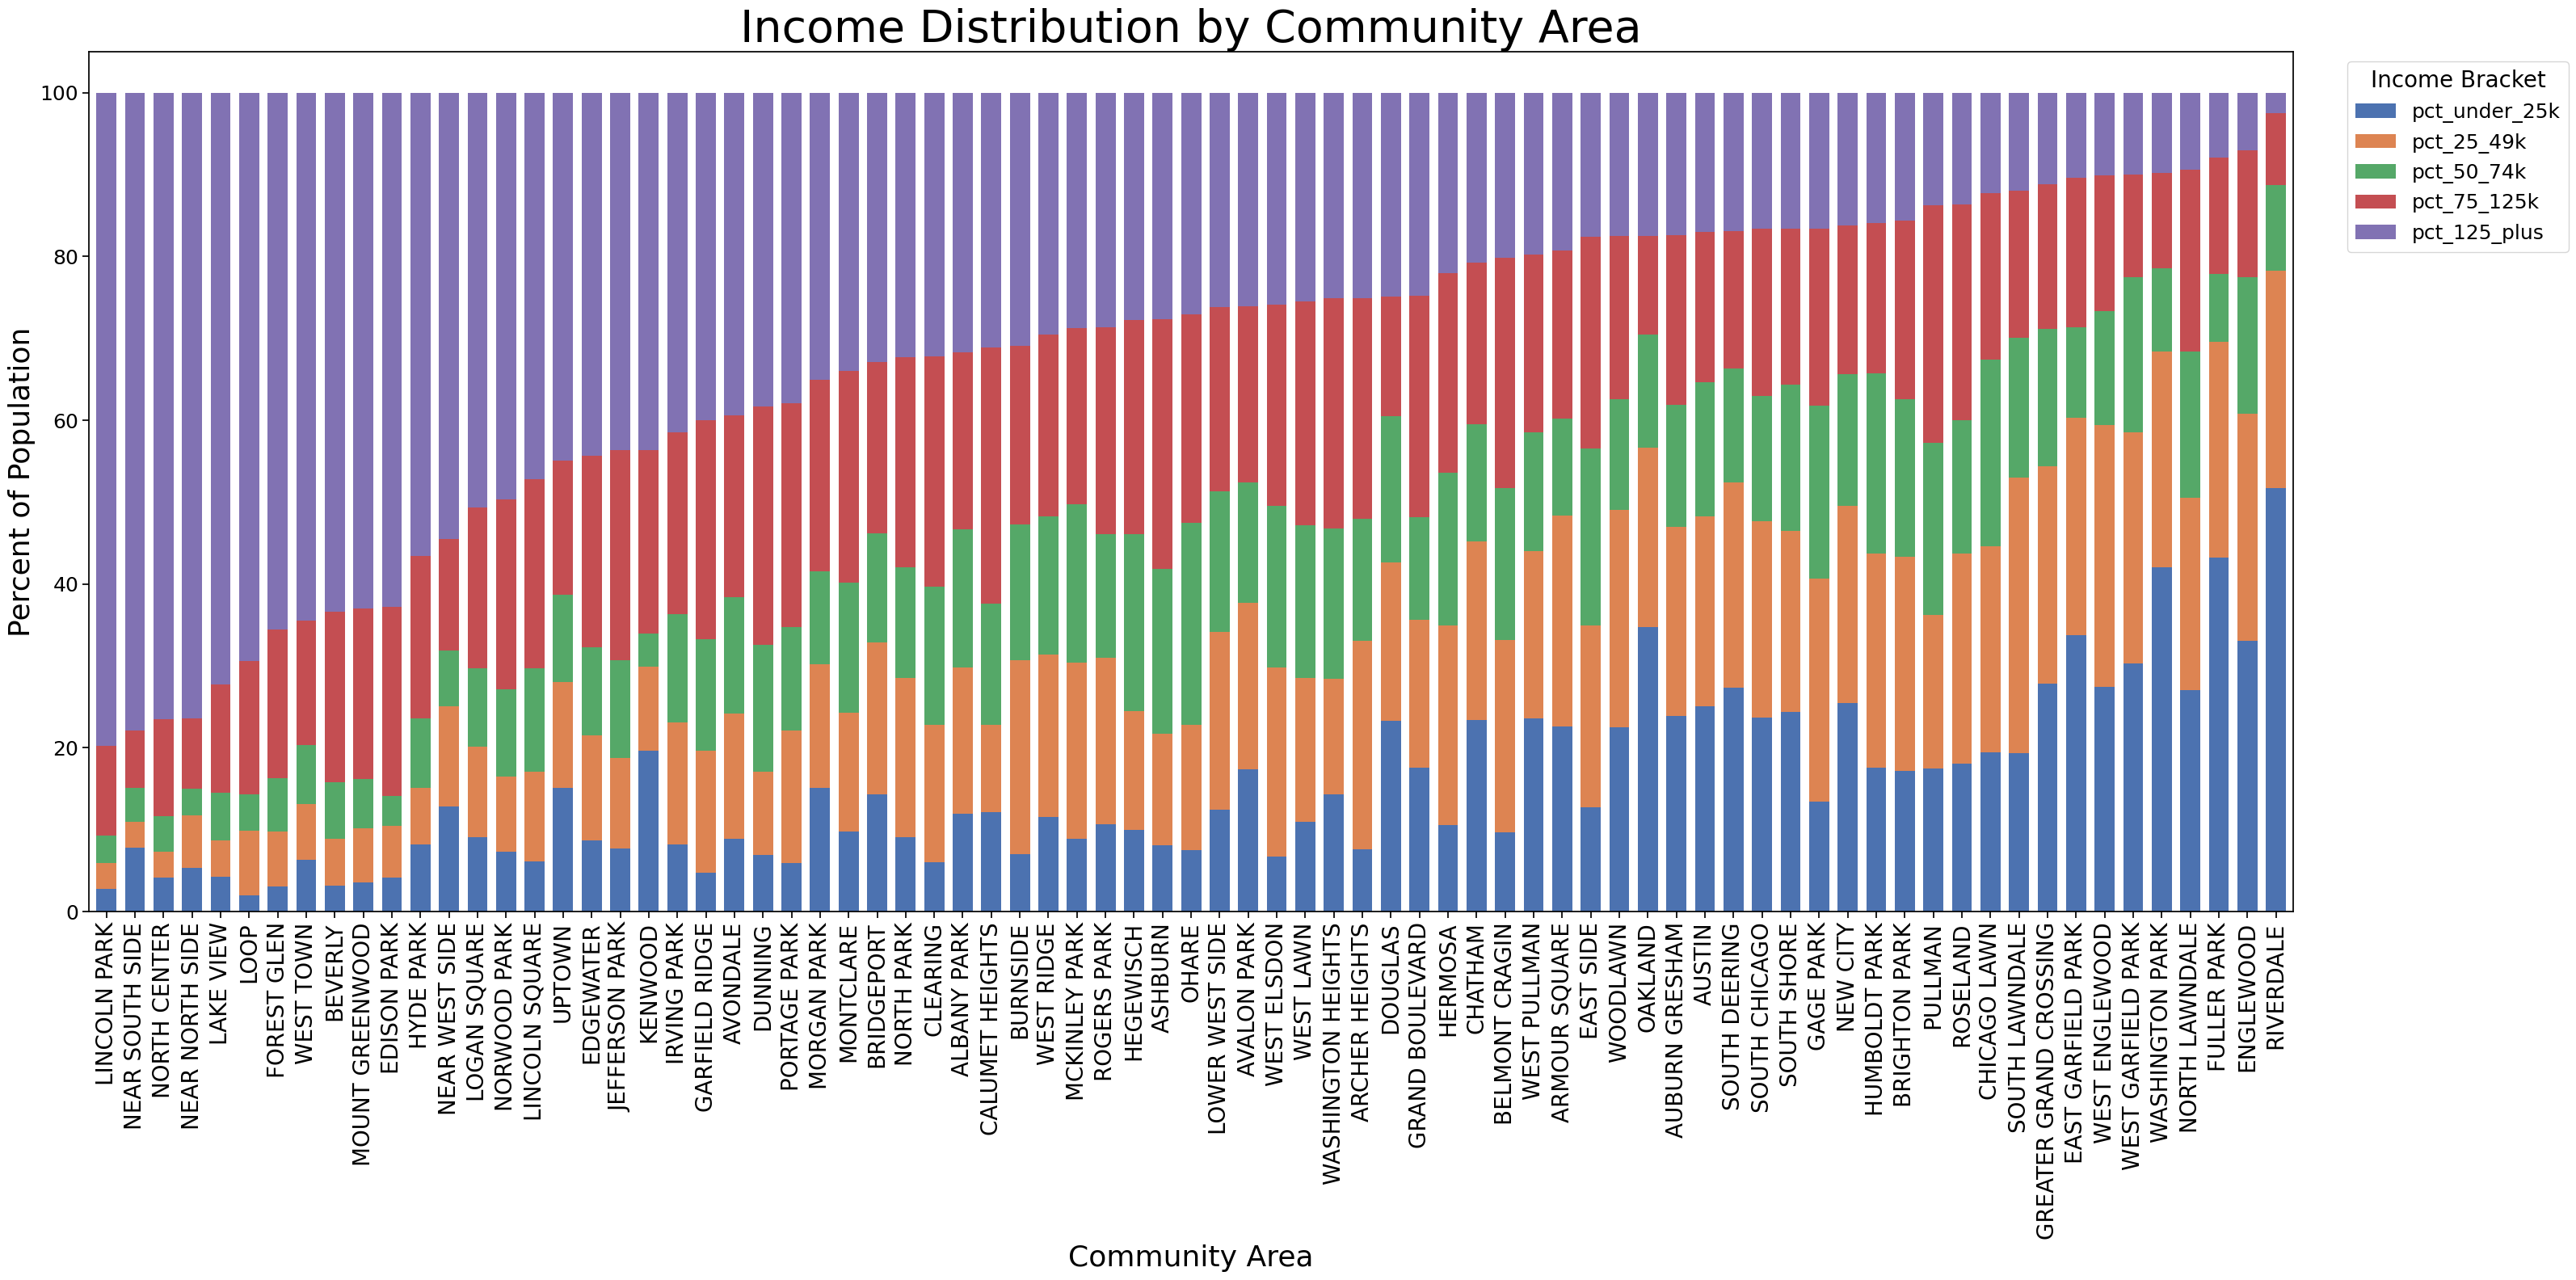

In [150]:
plot_df = chicago_dem[[
    'Community Area',
    'pct_under_25k',
    'pct_25_49k',
    'pct_50_74k',
    'pct_75_125k',
    'pct_125_plus'
]].set_index('Community Area')

plot_df_sorted = plot_df.sort_values('pct_125_plus', ascending=False)

fig, ax = plt.subplots(figsize=(32, 16)) 

plot_df_sorted.plot(
    kind='bar',
    stacked=True,
    width=0.7, 
    ax=ax
)

ax.set_ylabel('Percent of Population', fontsize=26)
ax.set_xlabel('Community Area', fontsize=26)
plt.title('Income Distribution by Community Area', fontsize = 40)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=18)

plt.legend(title='Income Bracket', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize = 18, title_fontsize = 20)


plt.tight_layout()
plt.show()

Here is a readable plot that shows income in each community. It is sorted by the communities with the highest to lowest percentage of citizens who makes more than $125,000. Essentially, it shows the highest to lowest socioeconomic status neighborhoods. 

##### Converting Stations onto the Geographic Map of Chicago (more merging)
*By Jenna Krinsky*

In [116]:
#I want to see how many stations are in each community 
#used help of AI to understand how to spatial join stations to communities in Chicago

stations_gdf = gpd.GeoDataFrame(
    stations_clean,
    geometry=gpd.points_from_xy(stations_clean['Longitude'], stations_clean['Latitude']),
    crs="EPSG:4326"
)
chicago = chicago.to_crs(epsg=4326)
stations_with_community = gpd.sjoin(
    stations_gdf,
    chicago[['community', 'geometry']],  # only keep needed columns
    how='left',
    predicate='within'
)


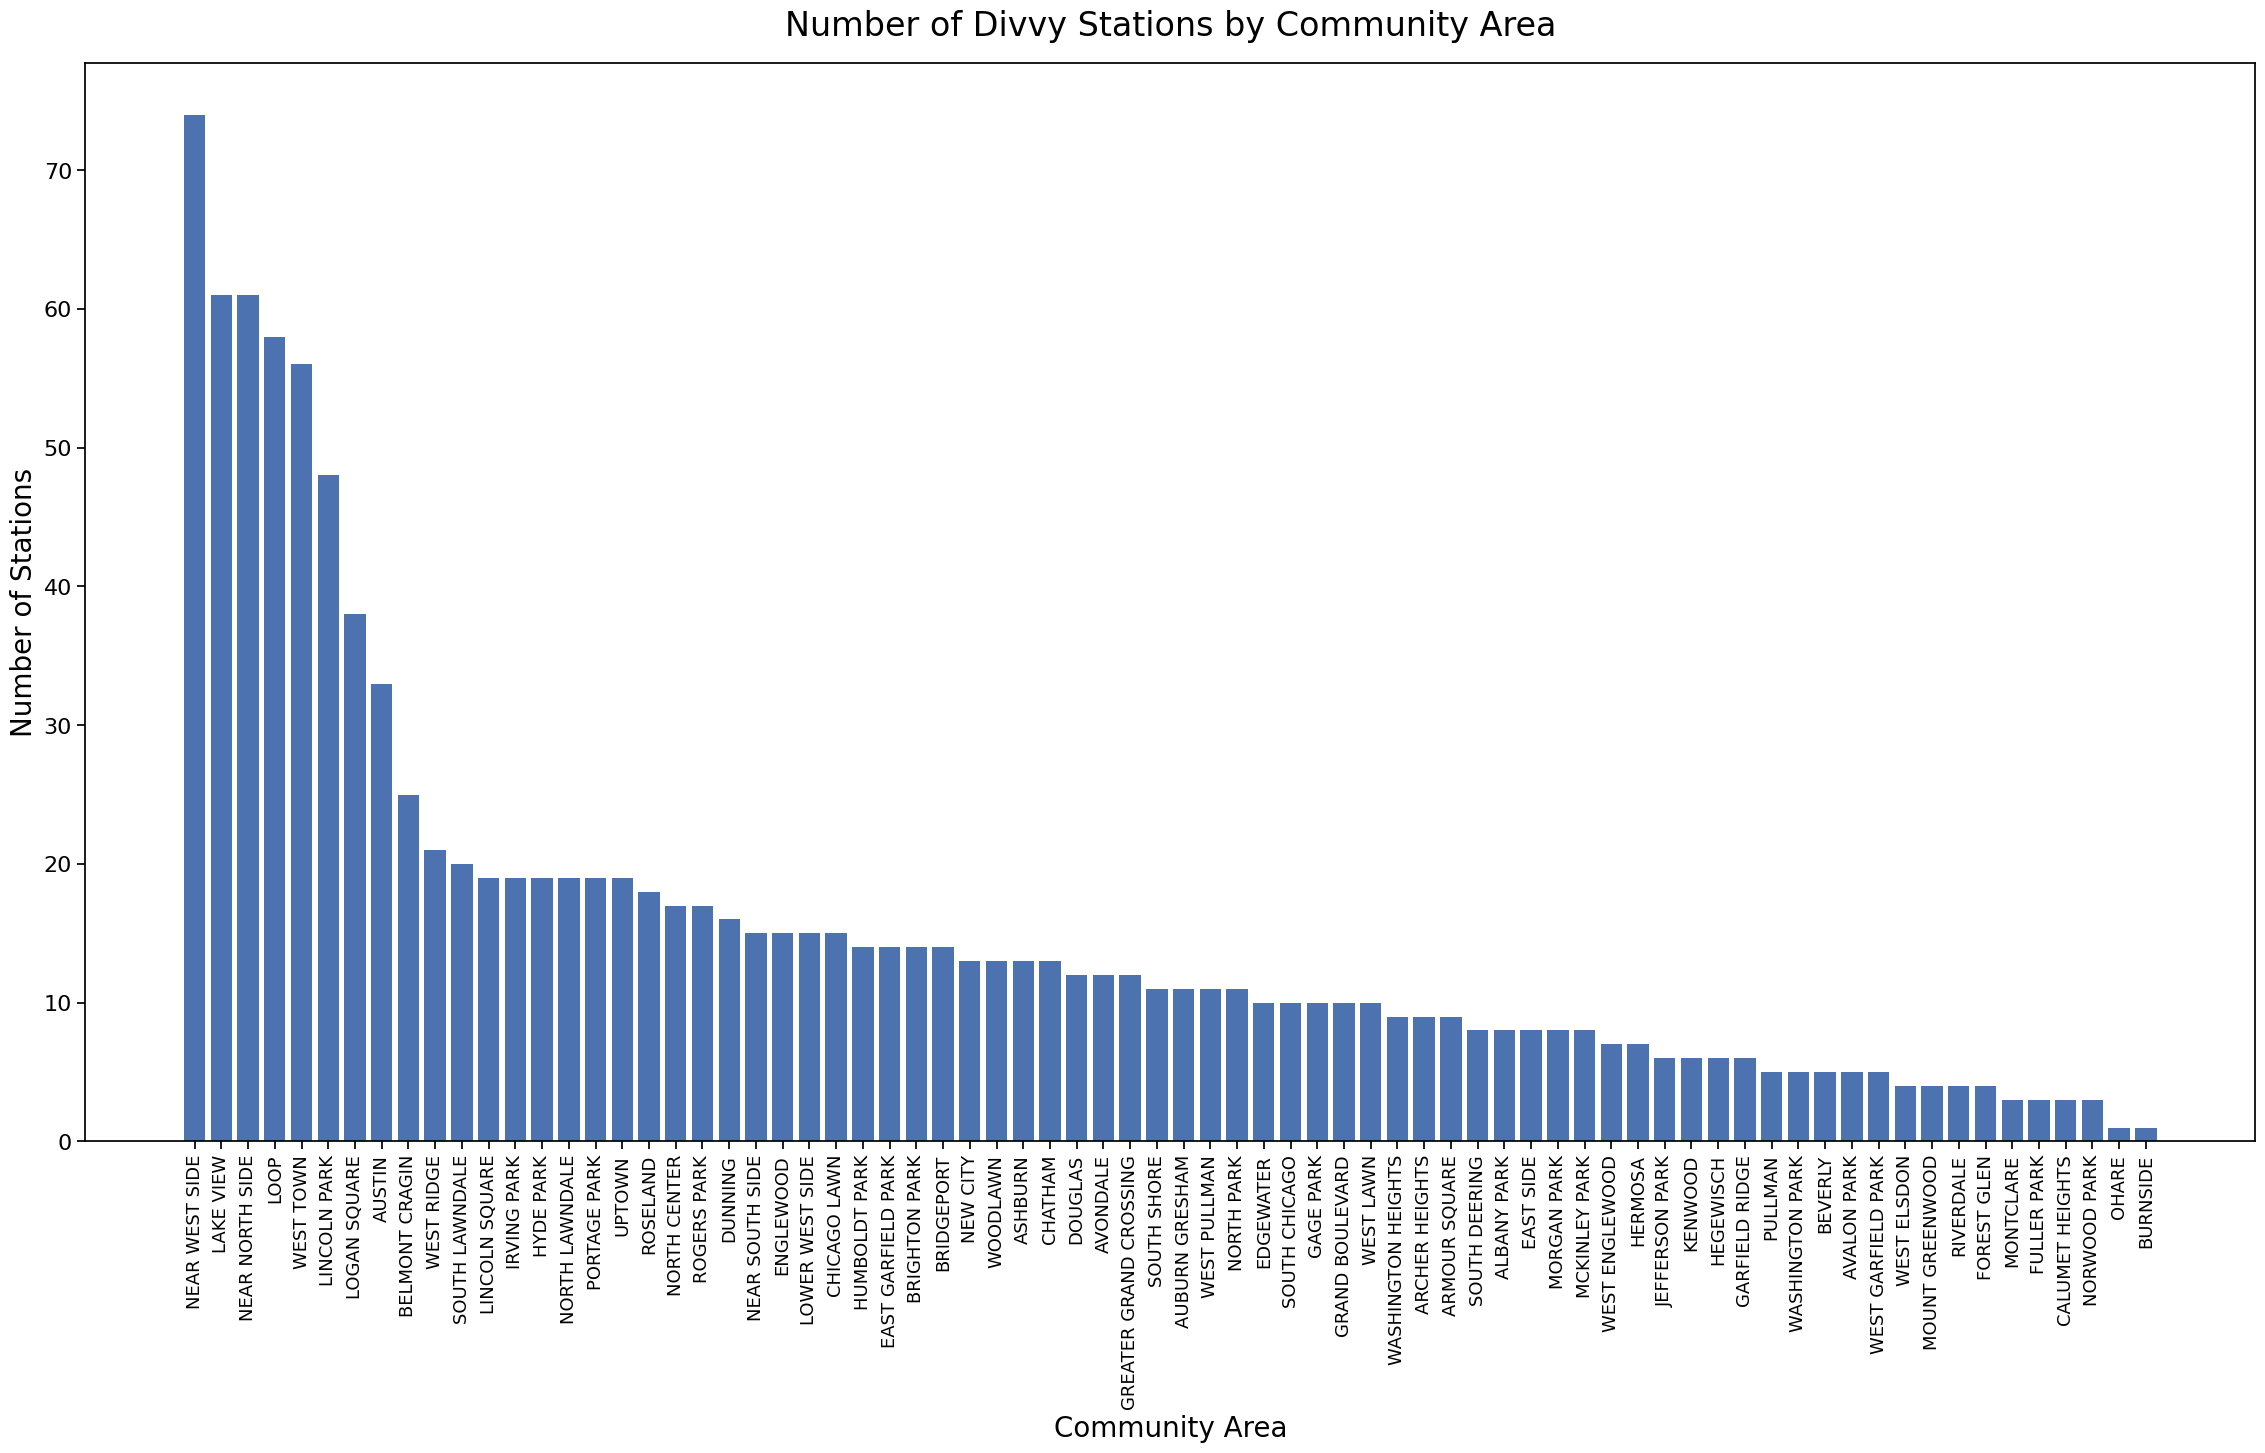

In [188]:
#using method from class to count number of divvy bike stops per community

station_counts = (
    stations_with_community
    .groupby('community')
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(28, 14))

ax.bar(
    station_counts.index,
    station_counts.values
)
ax.set_title('Number of Divvy Stations by Community Area', fontsize=24, pad=20)

ax.set_xlabel('Community Area', fontsize=20)
ax.set_ylabel('Number of Stations', fontsize=20)

ax.set_xticks(range(len(station_counts.index)));
ax.set_xticklabels(station_counts.index, rotation=90, fontsize=13);
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=16);

The above graph shows how many Divvy Bike stops are in each community.

### Correlation of socioeconomic status to number of Divvy stations
*By Jenna Krinsky*

In [131]:
#need to merge the # of stations/community with community demographic df

station2 = station_counts.reset_index()
station2.columns = ['community', 'n_stations']
#need it to be a df

In [159]:

#making sure can merge on the community areas

chicago_dem['community'] = chicago_dem['community'].str.upper().str.strip()
station2['community'] = station2['community'].str.upper().str.strip()


In [161]:
#merging the two datasets to see how many stations there are and the % of citizens who make over $125k in each community
chicago_dem = station2.merge(
    chicago_dem,
    on='community',
)

chicago_dem.head()

,community,n_stations,area_numbe,area_num_1,shape_area,shape_len,geometry,community_name,Community Area,ACS Year,...,Other Race,Multiracial,White Not Hispanic or Latino,Hispanic or Latino,Record ID,pct_under_25k,pct_25_49k,pct_50_74k,pct_75_125k,pct_125_plus
0,BURNSIDE,1,47.0,47,1.699598e+07,18137.944253,"POLYGON ((-87.58737 41.72326, -87.58733 41.723...",BURNSIDE,BURNSIDE,2023,...,0,183,40,108,2023_BURNSIDE,7.045455,23.636364,16.590909,21.818182,30.909091
1,OHARE,1,76.0,76,3.718356e+08,173625.984660,"MULTIPOLYGON (((-87.83658 41.9864, -87.83658 4...",OHARE,OHARE,2023,...,"1,110","1,176","9,418","3,013",2023_OHARE,7.533443,15.254635,24.689040,25.416569,27.106313
2,MONTCLARE,3,18.0,18,2.757639e+07,22404.852145,"POLYGON ((-87.78942 41.91751, -87.79152 41.918...",MONTCLARE,MONTCLARE,2023,...,"3,851","1,398","4,683","7,515",2023_MONTCLARE,9.743910,14.490943,15.927545,25.827608,34.009994
3,NORWOOD PARK,3,10.0,10,1.219591e+08,80368.374378,"POLYGON ((-87.78002 41.99741, -87.78049 41.997...",NORWOOD PARK,NORWOOD PARK,2023,...,"1,759","3,819","27,986","7,802",2023_NORWOOD PARK,7.270156,9.165488,10.749646,23.187176,49.627534
4,CALUMET HEIGHTS,3,48.0,48,4.882624e+07,32925.365871,"POLYGON ((-87.54568 41.72282, -87.546 41.72279...",CALUMET HEIGHTS,CALUMET HEIGHTS,2023,...,158,284,28,498,2023_CALUMET HEIGHTS,12.168218,10.617029,14.856946,31.230610,31.127198


In [162]:
chicago_dem['n_stations'].corr(chicago_dem['pct_125_plus'])


np.float64(0.508685457885125)

The number of bikes in a community and the % of people who make more than $125k in each community has a moderate positive correlation at .51. This means that usually, wealthier neighborhoods have more Divvy bike stations.

Text(0.5, 1.0, 'Divvy Station Density vs Neighborhood Wealth')

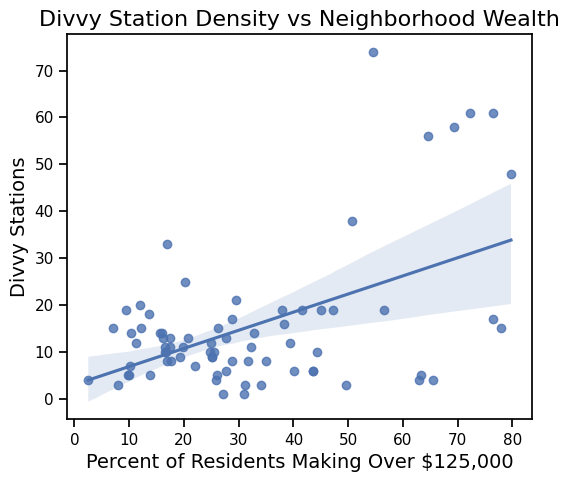

In [163]:
plt.figure(figsize=(6, 5))

sns.regplot(
    data=chicago_dem,
    x='pct_125_plus',
    y='n_stations'
)

plt.xlabel('Percent of Residents Making Over $125,000', fontsize=14)
plt.ylabel('Divvy Stations', fontsize=14)
plt.title('Divvy Station Density vs Neighborhood Wealth', fontsize=16)


Close-up of corr between % of residents in a community making over 125k and number of Divvy bike stations in that community. 

In [183]:
race_cols = [
    'White', 'Black or African American',
    'American Indian or Alaska Native', 'Asian',
    'Native Hawaiian or Pacific Islander', 'Other Race', 'Multiracial',
    'White Not Hispanic or Latino', 'Hispanic or Latino'
]

# Turned out to be unecessary but now all cols with #s are ints/numeric
for col in race_cols:
    chicago_dem[col] = (
        chicago_dem[col]
        .astype(str)
        .str.replace(',', '', regex=True)
        .astype(float)
    )

Text(0.5, 1.0, 'Correlations between Chicago Community Features')

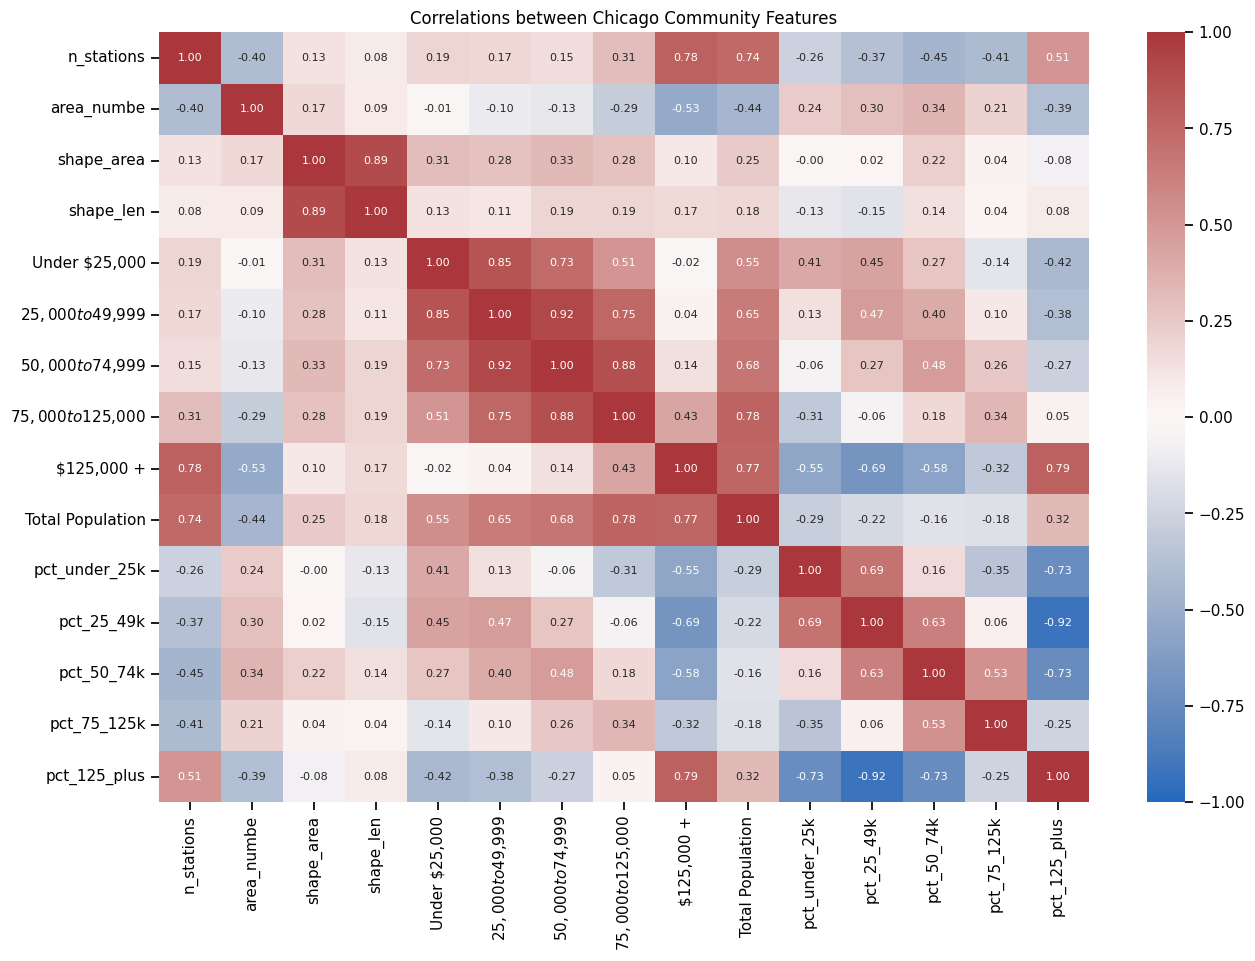

In [190]:
chicago_num = chicago_dem.select_dtypes(include=['number'])
chicago_num = chicago_num.drop(["ACS Year", 'White', 'Black or African American',
    'American Indian or Alaska Native', 'Asian',
    'Native Hawaiian or Pacific Islander', 'Other Race', 'Multiracial',
    'White Not Hispanic or Latino', 'Hispanic or Latino'] , axis = 1)
matrix = chicago_num.corr()
plt.figure(figsize=(15, 10))

sns.heatmap(matrix, cmap='vlag', annot=True, fmt=".2f", vmin = -1, vmax=1, annot_kws={"size": 8});
plt.title("Correlations between Chicago Community Features")


Number of stations is positively correlated with % of 125k+ but negatively correlated with all other income groups. Also, total population and is generally similarly correlated to each income group (except $125k+), so that is not the only reason for more stations. 

## Exploratory data analysis

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.**

### Analysis 1
*By \<Name of person doing the analysis>*

### Analysis 2
*By \<Name of person doing the analysis>*

### Analysis 3
*By \<Name of person doing the analysis>*

### Analysis 4
*By \<Name of person doing the analysis>*

## Other sections

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.**

Put each model in a section of its name and mention the name of the team-member tuning the model. Below is an example:

## Conclusions and Recommendations to stakeholder(s)

You may or may not have code to put in this section. Delete this section if it is irrelevant.